# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hcfc141b"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[0.2566666666666666 0.2444444444444444 0.23222222222222222 ... 0.514 0.58 0.58] [0.2566666666666666 0.24444444444444438 0.24212121212121207 ... 0.5285714285714286 0.58 0.58] [0.2566666666666666 0.24939393939393936 0.2764444444444444 ... 0.5285714285714285 0.58 0.58] [0.2566666666666666 0.2751724137931034 0.2936781609195402 ... 0.5285714285714285 0.58 0.58] [0.2566666666666666 0.24444444444444438 0.24758620689655172 ... 0.5285714285714286 0.58 0.58] [0.2566666666666666 0.2444444444444444 0.2322222222222222 ... 0.5285714285714285 0.58 0.58]] [[0.2 0.2 0.2 ... 0.575 0.6375 0.7] [0.2 0.2 0.21636363636363637 ... 0.6933333333333332 0.6966666666666667 0.7] [0.2 0.2081818181818182 0.26071428571428573 ... 0.575 0.6375 0.7] [0.2 0.24454545454545454 0.28909090909090907 ... 0.575 0.6375 0.7] [0.2 0.2 0.22227272727272726 ... 0.575 0.6375000000000001 0.7] [0.2 0.2 0.2 ... 0.575 0.6375 0.7]] [[0.35 0.35 0.35 ... 0.84 0.84 0.84] [0.35 0.35 0.35 ... 0.84 0.84 0.84] [0.35 0.35 0.35 ... 0.84 0.84 0.84] [0.35 0.35 0.35 ... 0.84 0.84 0.84] [0.35 0.35 0.35 ... 0.84 0.84 0.84] [0.35 0.35 0.35 ... 0.84 0.84 0.84]] ... [[23.41 23.41 23.41 ... 26.03333333333333 25.866666666666664 25.8575] [23.41 23.41 23.41 ... 26.22 26.03875 25.8575] [23.41 23.41 23.41 ... 25.805 25.835185185185185 25.8575] [23.41 23.41 23.41 ... 25.73 25.84305555555556 25.8575] [23.41 23.41 23.41 ... 25.655 25.850925925925925 25.8575] [23.41 23.41 23.41 ... 25.58 25.858796296296294 25.8575]] [[23.236666666666665 23.236666666666665 23.236666666666665 ... 25.900333333333336 25.964 25.9575] [23.236666666666665 23.236666666666665 23.236666666666665 ... 26.09 26.02375 25.9575] [23.236666666666665 23.236666666666665 23.236666666666665 ... 26.23 26.079333333333334 25.9575] [23.236666666666665 23.236666666666665 23.236666666666665 ... 26.060024691358024 26.0505 25.9575] [23.236666666666665 23.236666666666665 23.236666666666665 ... 25.89004938271605 26.021666666666665 25.9575] [23.236666666666665 23.236666666666665 23.236666666666665 ... 25.720074074074073 25.992833333333333 25.9575]] [[23.24 23.24 23.24 ... 25.921666666666667 25.83666666666667 25.83666666666667] [23.24 23.24 23.24 ... 26.15 25.83666666666667 25.83666666666667] [23.24 23.24 23.24 ... 25.81 25.83666666666667 25.83666666666667] [23.24 23.24 23.24 ... 25.837916666666665 25.83666666666667 25.83666666666667] [23.24 23.24 23.24 ... 25.865833333333335 25.83666666666667 25.83666666666667] [23.24 23.24 23.24 ... 25.89375 25.83666666666667 25.83666666666667]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[0.2566666666666666 0.2444444444444444 0.23222222222222222 ... 0.514 0.58 0.58] [0.2566666666666666 0.24444444444444438 0.24212121212121207 ... 0.5285714285714286 0.58 0.58] [0.2566666666666666 0.24939393939393936 0.2764444444444444 ... 0.5285714285714285 0.58 0.58] [0.2566666666666666 0.2751724137931034 0.2936781609195402 ... 0.5285714285714285 0.58 0.58] [0.2566666666666666 0.24444444444444438 0.24758620689655172 ... 0.5285714285714286 0.58 0.58] [0.2566666666666666 0.2444444444444444 0.2322222222222222 ... 0.5285714285714285 0.58 0.58]] [[0.2 0.2 0.2 ... 0.575 0.6375 0.7] [0.2 0.2 0.21636363636363637 ... 0.6933333333333332 0.6966666666666667 0.7] [0.2 0.2081818181818182 0.26071428571428573 ... 0.575 0.6375 0.7] [0.2 0.24454545454545454 0.28909090909090907 ... 0.575 0.6375 0.7] [0.2 0.2 0.22227272727272726 ... 0.575 0.6375000000000001 0.7] [0.2 0.2 0.2 ... 0.575 0.6375 0.7]] [[0.35 0.35 0.35 ... 0.84 0.84 0.84] [0.35 0.35 0.35 ... 0.84 0.84 0.84] [0.35 0.35 0.35 ... 0.84 0.84 0.84] [0.35 0.35 0.35 ... 0.84 0.84 0.84] [0.35 0.35 0.35 ... 0.84 0.84 0.84] [0.35 0.35 0.35 ... 0.84 0.84 0.84]] ... [[23.41 23.41 23.41 ... 26.03333333333333 25.866666666666664 25.8575] [23.41 23.41 23.41 ... 26.22 26.03875 25.8575] [23.41 23.41 23.41 ... 25.805 25.835185185185185 25.8575] [23.41 23.41 23.41 ... 25.73 25.84305555555556 25.8575] [23.41 23.41 23.41 ... 25.655 25.850925925925925 25.8575] [23.41 23.41 23.41 ... 25.58 25.858796296296294 25.8575]] [[23.236666666666665 23.236666666666665 23.236666666666665 ... 25.900333333333336 25.964 25.9575] [23.236666666666665 23.236666666666665 23.236666666666665 ... 26.09 26.02375 25.9575] [23.236666666666665 23.236666666666665 23.236666666666665 ... 26.23 26.079333333333334 25.9575] [23.236666666666665 23.236666666666665 23.236666666666665 ... 26.060024691358024 26.0505 25.9575] [23.236666666666665 23.236666666666665 23.236666666666665 ... 25.89004938271605 26.021666666666665 25.9575] [23.236666666666665 23.236666666666665 23.236666666666665 ... 25.720074074074073 25.992833333333333 25.9575]] [[23.24 23.24 23.24 ... 25.921666666666667 25.83666666666667 25.83666666666667] [23.24 23.24 23.24 ... 26.15 25.83666666666667 25.83666666666667] [23.24 23.24 23.24 ... 25.81 25.83666666666667 25.83666666666667] [23.24 23.24 23.24 ... 25.837916666666665 25.83666666666667 25.83666666666667] [23.24 23.24 23.24 ... 25.865833333333335 25.83666666666667 25.83666666666667] [23.24 23.24 23.24 ... 25.89375 25.83666666666667 25.83666666666667]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hcfc141b' (lon: 6, lat: 12, year: 31, month: 12)> Size: 214kB
<Quantity([[[[ 0.57        0.69666667  0.63       ...  1.44        1.39
     1.60666667]
   [ 2.14        1.7         1.86       ...  2.685       2.81
     2.93      ]
   [ 3.15        3.265       3.41       ...  4.45        4.645
     4.715     ]
   ...
   [23.36       23.225      23.285      ... 23.56       23.4
    23.365     ]
   [23.23       23.22       23.16       ... 23.325      23.325
    23.255     ]
   [23.1        22.99       22.98       ... 23.26       23.41
    23.23666667]]

  [[ 0.57        0.69666667  0.66666667 ...  1.455       1.42888889
     1.60666667]
   [ 2.14        1.755       1.91222222 ...  2.7375      2.85666667
     2.93      ]
   [ 3.15        3.265       3.4        ...  4.45        4.675
     4.86666667]
...
   [26.43258333 26.254      26.163      ... 26.02233333 26.13733333
    26.15433333]
   [26.10041667 25.99725    25.95102778 ... 25.89077778 26.10863889
    26.247     ]
   [26.24833333 26.10361111 26.03027778 ... 25.74866667 25.8587963
    25.99283333]]

  [[ 1.94        2.035       2.28       ...  3.385       3.8
     4.02      ]
   [ 4.32        4.13        4.51       ...  5.72        6.18
     6.31      ]
   [ 6.41        6.48        6.68       ...  7.99        8.25
     8.55      ]
   ...
   [26.4585     26.30175    26.1745     ... 26.05225    26.1105
    26.1545    ]
   [26.08825    26.01475    25.98666667 ... 25.90016667 26.1095
    26.302     ]
   [26.25       26.1075     26.0125     ... 25.694      25.8575
    25.9575    ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 248B 1994 1995 1996 1997 1998 ... 2021 2022 2023 2024
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[0.5700000000000001 0.6966666666666667 0.63 ... 23.26 23.41 23.236666666666665] [0.5700000000000001 0.6966666666666667 0.6666666666666667 ... 23.299166666666668 23.41 23.236666666666665] [0.5700000000000001 0.6966666666666667 0.7033333333333334 ... 23.338333333333335 23.41 23.236666666666665] ... [1.7166666666666666 1.7675 2.12 ... 26.067666666666668 26.03333333333333 25.900333333333336] [1.94 1.90125 2.21 ... 25.732 25.866666666666664 25.964] [1.94 2.035 2.28 ... 25.694 25.8575 25.9575]] [[0.5700000000000001 0.6966666666666667 0.63 ... 23.26 23.41 23.236666666666665] [0.5700000000000001 0.6966666666666667 0.6666666666666666 ... 23.299166666666668 23.41 23.236666666666665] [0.6136363636363636 0.6966666666666667 0.8142105263157895 ... 23.53526315789474 23.41 23.236666666666665] ... [1.744285714285714 2.171666666666667 2.293333333333333 ... 25.64 26.22 26.09] [1.94 2.1033333333333335 2.2866666666666666 ... 25.667 26.03875 26.02375] [1.94 2.035 2.28 ... 25.694 25.8575 25.9575]] [[0.5700000000000001 0.6966666666666667 0.63 ... 23.26 23.41 23.236666666666665] [0.5918181818181819 0.6966666666666667 0.7221052631578947 ... 23.39763157894737 23.41 23.236666666666665] [0.7266666666666667 0.6966666666666667 0.9805263157894737 ... 23.830657894736845 23.41 23.236666666666665] ... [1.744285714285714 1.7004166666666667 1.8949999999999998 ... 25.92 25.805 26.23] [1.94 1.8900694444444444 2.101111111111111 ... 25.798666666666666 25.835185185185185 26.079333333333334] [1.94 2.035 2.28 ... 25.694 25.8575 25.9575]] [[0.5700000000000001 0.6966666666666667 0.63 ... 23.26 23.41 23.236666666666665] [0.6644827586206897 0.6966666666666667 0.7918181818181818 ... 23.51892857142857 23.41 23.236666666666665] [0.7589655172413794 0.6966666666666667 0.9536363636363636 ... 23.777857142857144 23.41 23.236666666666665] ... [1.7442857142857142 1.745138888888889 1.922222222222222 ... 25.784055555555558 25.73 26.060024691358024] [1.94 1.90125 2.1283333333333334 ... 25.782 25.84305555555556 26.0505] [1.94 2.035 2.28 ... 25.694 25.8575 25.9575]] [[0.5700000000000001 0.6966666666666667 0.63 ... 23.26 23.41 23.236666666666665] [0.5700000000000001 0.6966666666666667 0.6666666666666666 ... 23.299166666666668 23.41 23.236666666666665] [0.617241379310345 0.6966666666666667 0.7659090909090909 ... 23.448214285714286 23.41 23.236666666666665] ... [1.7442857142857142 1.7675 1.9494444444444443 ... 25.64811111111111 25.655 25.89004938271605] [1.94 1.90125 2.1555555555555554 ... 25.765333333333334 25.850925925925925 26.021666666666665] [1.94 2.035 2.28 ... 25.694 25.8575 25.9575]] [[0.5700000000000001 0.6966666666666667 0.63 ... 23.26 23.41 23.236666666666665] [0.5700000000000001 0.6966666666666667 0.6666666666666667 ... 23.299166666666668 23.41 23.236666666666665] [0.5700000000000001 0.6966666666666667 0.7033333333333333 ... 23.338333333333335 23.41 23.236666666666665] ... [1.7442857142857142 1.7675 1.9766666666666668 ... 25.512166666666666 25.58 25.720074074074073] [1.94 1.9012499999999999 2.1827777777777775 ... 25.748666666666665 25.858796296296294 25.992833333333333] [1.94 2.035 2.28 ... 25.694 25.8575 25.9575]]]
Units,ppt


### Longitudinal-mean

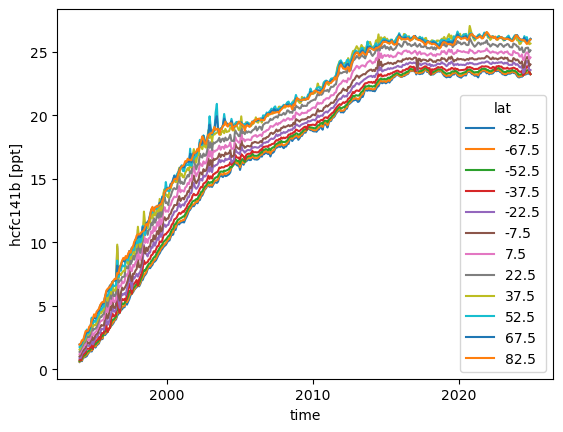

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

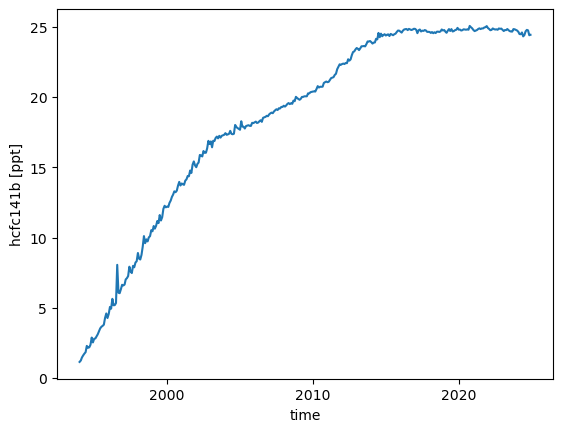

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

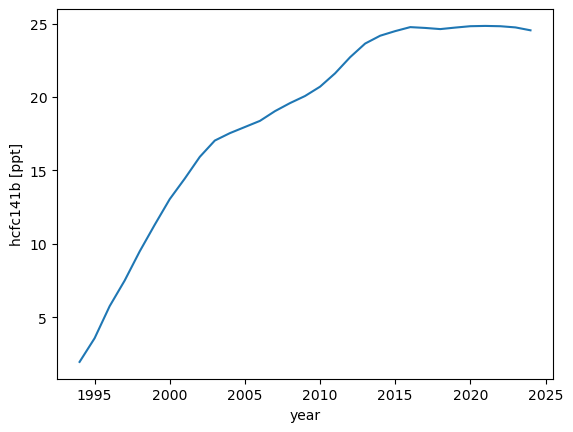

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 5kB
Dimensions:               (lat: 12, eof: 12, year: 31)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 248B 1994 1995 1996 ... 2022 2023 2024
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.3982 0.137 ... 0.05329
    principal-components  (year, eof) float64 3kB [] -2.284 ... -2.989e-15

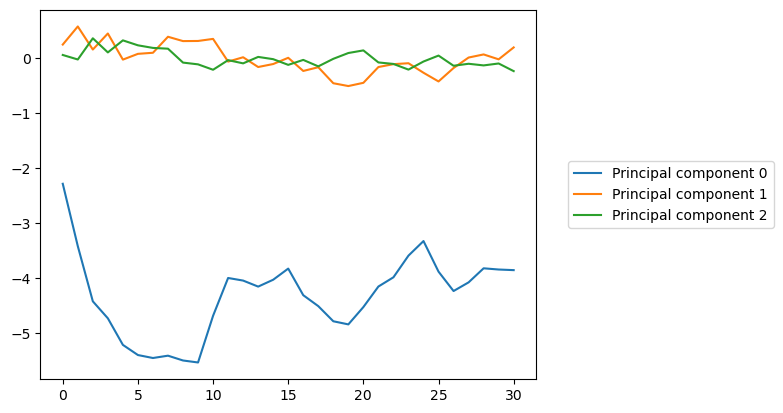

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

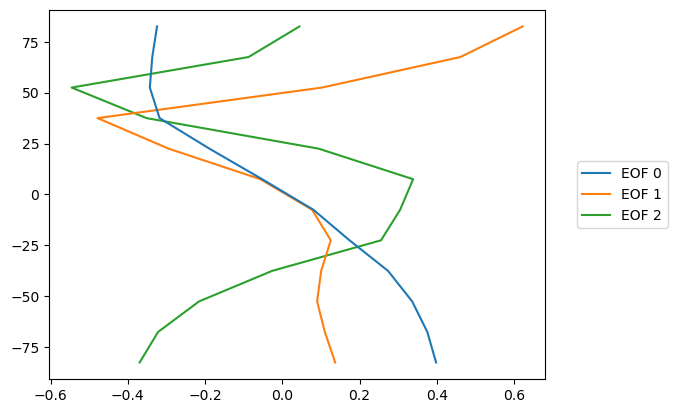

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

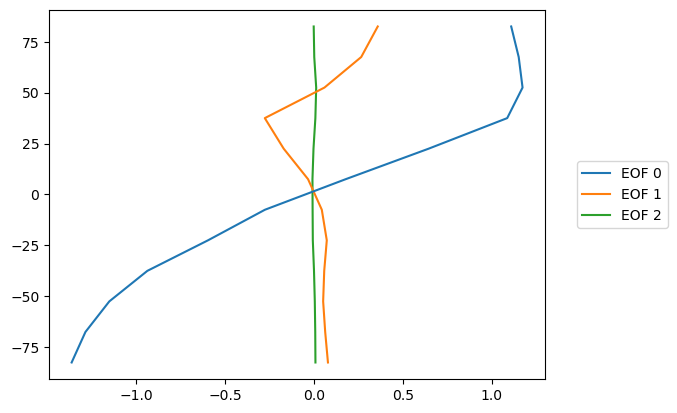

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.3982408476666254] [0.37554165767436587] [0.33631054549176115] [0.27374939510972907] [0.17401300643292278] [0.08051045064620993] [-0.05217339221648006] [-0.1886998033450981] [-0.31780312956700274] [-0.3430245110255545] [-0.3366864465328751] [-0.32436804860263063]]
Units,ppt
Magnitude,[[-2.2836185422458] [-3.417569784180514] [-4.42098247001882] [-4.729863055231735] [-5.2129531018053585] [-5.39766184381359] [-5.451687897777083] [-5.409247276900662] [-5.496702542219602] [-5.532899508980888] [-4.684153203025669] [-3.996554791330168] [-4.043686063574584] [-4.153294470390688] [-4.028285300512744] [-3.8258757460771387] [-4.309354884092413] [-4.508405353745738] [-4.783589704056226] [-4.840354275962449] [-4.525320572976724] [-4.151808317681058] [-3.9839587797729688] [-3.5901526113799633] [-3.32507090666568] [-3.8810511653540853] [-4.233743641557512] [-4.076413005442462] [-3.8206411988732736] [-3.8426034670606803] [-3.8537837282905736]]
Units,dimensionless


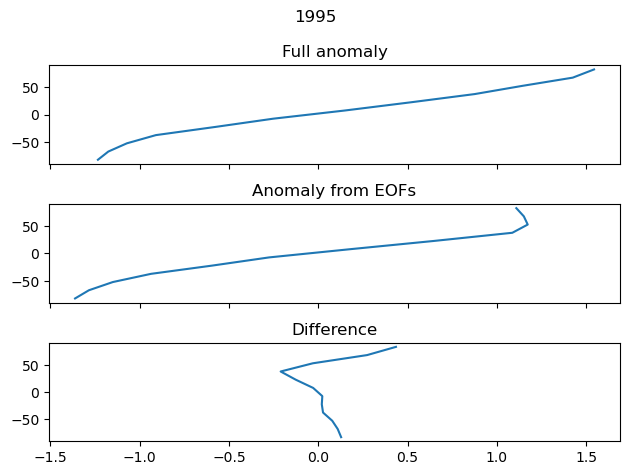

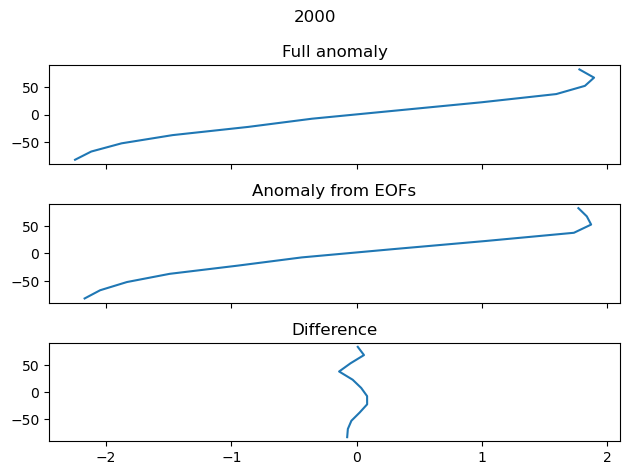

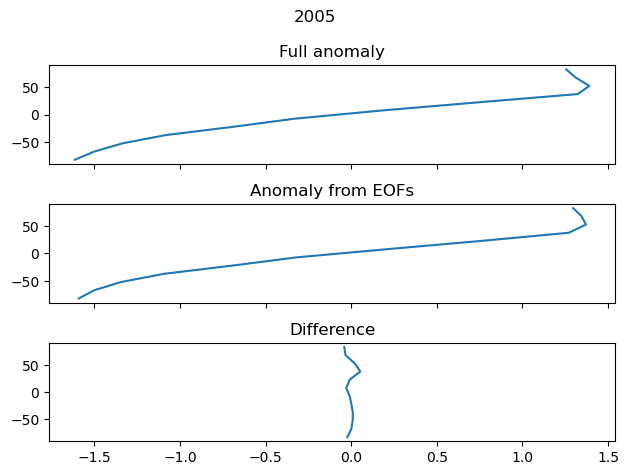

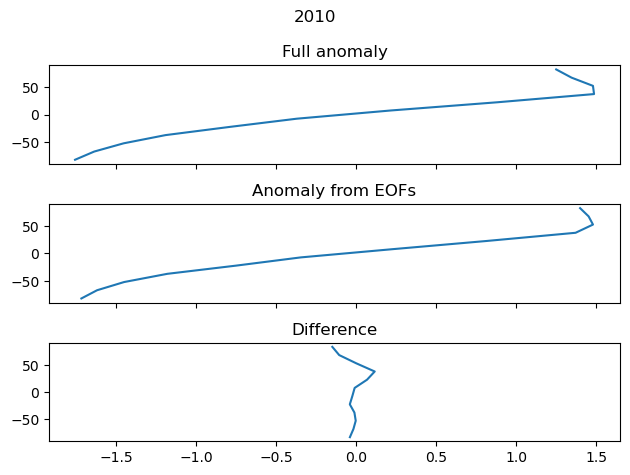

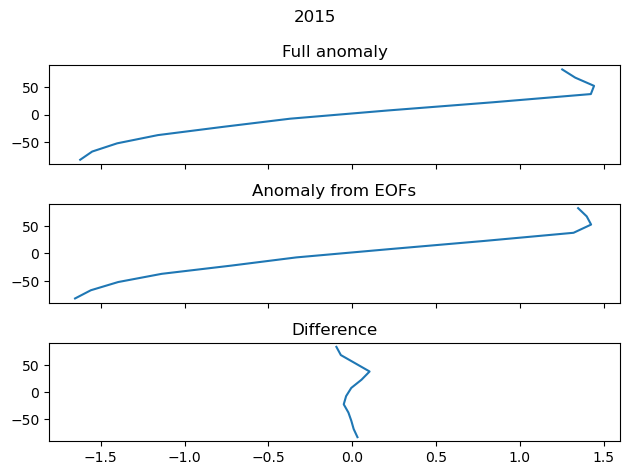

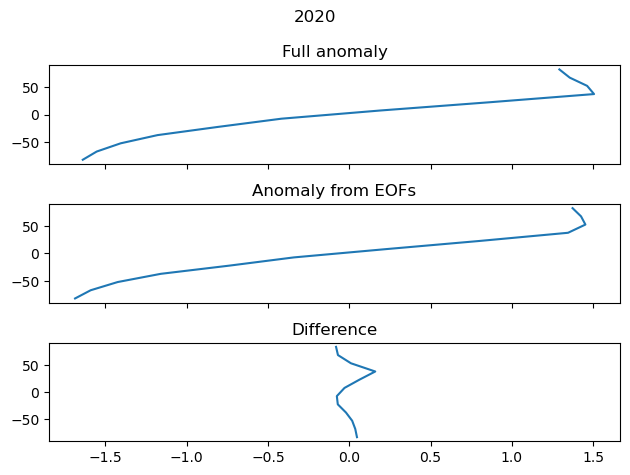

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:00<00:00, 18272.84it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:00<00:00, 15923.19it/s]

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:00<00:00, 18328.65it/s]

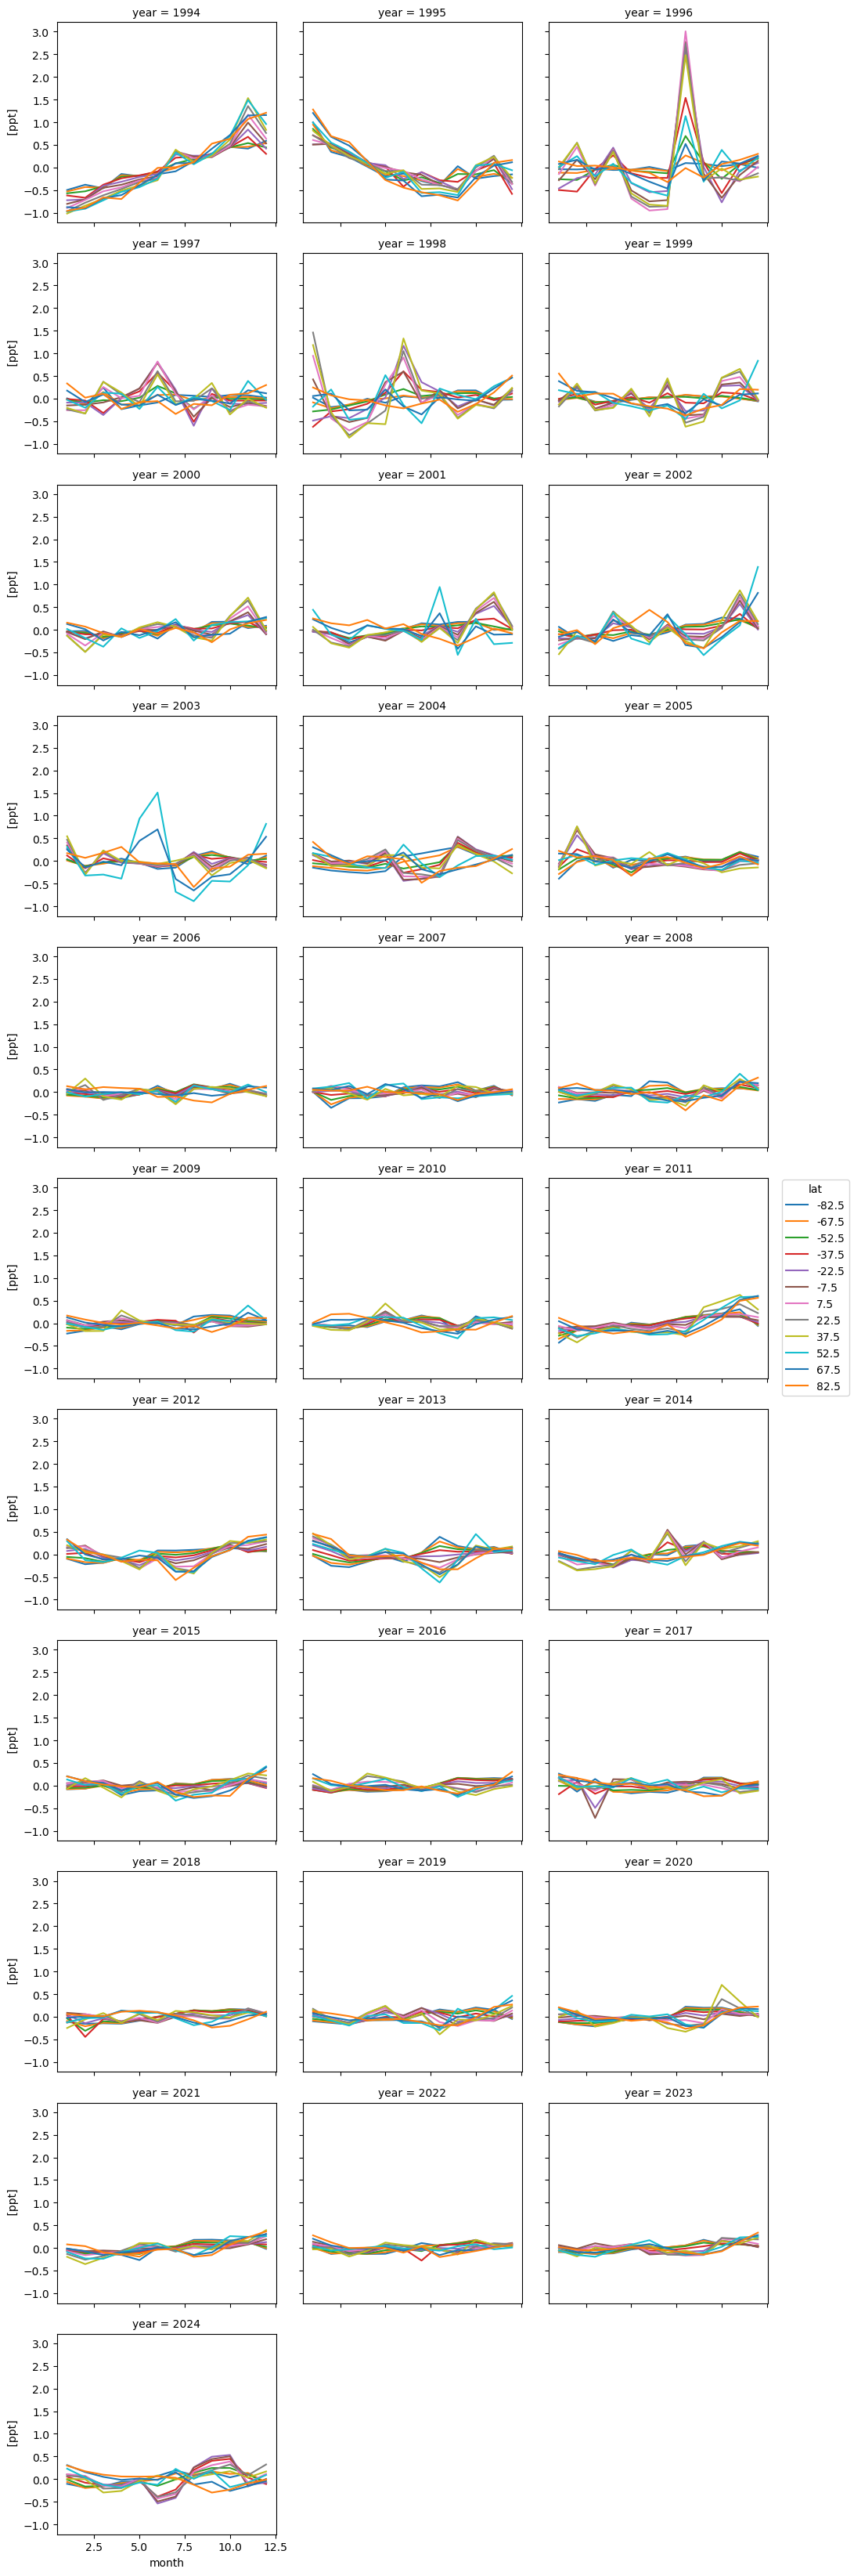

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

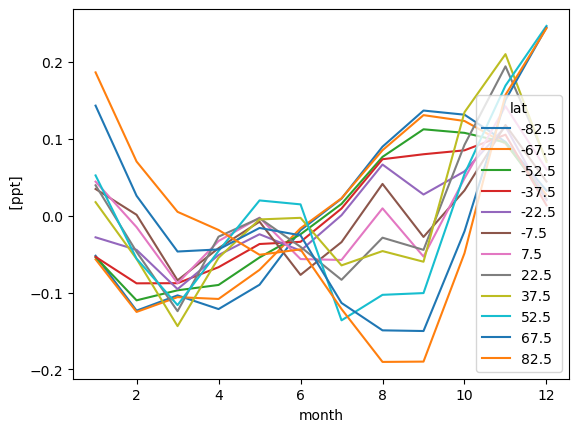

In [22]:
seasonality.plot.line(hue="lat")

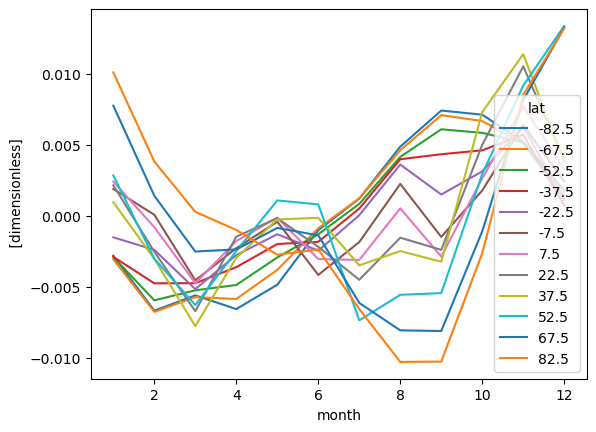

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[1.9570549979317207 3.5714078920315306 5.753880866392085 7.500907243903729 9.488094963486676 11.302508971531092 13.050336395023221 14.449190228594325 15.92937004182641 17.04030152062624 17.544207805840028 17.96174880686711 18.379507480169494 19.042478046450167 19.59050116559605 20.073807987596123 20.70900215535002 21.619110120576863 22.717832636045724 23.647762717856995 24.181629869670193 24.495487584830126 24.767263633590385 24.711160540299204 24.63297921067129 24.736394609297008 24.829711737917904 24.848888007271853 24.82808603499686 24.74764653274769 24.550086596692562]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.3982408476666254] [0.37554165767436587] [0.33631054549176115] [0.27374939510972907] [0.17401300643292278] [0.08051045064620993] [-0.05217339221648006] [-0.1886998033450981] [-0.31780312956700274] [-0.3430245110255545] [-0.3366864465328751] [-0.32436804860263063]]
Units,ppt
Magnitude,[[-2.2836185422458] [-3.417569784180514] [-4.42098247001882] [-4.729863055231735] [-5.2129531018053585] [-5.39766184381359] [-5.451687897777083] [-5.409247276900662] [-5.496702542219602] [-5.532899508980888] [-4.684153203025669] [-3.996554791330168] [-4.043686063574584] [-4.153294470390688] [-4.028285300512744] [-3.8258757460771387] [-4.309354884092413] [-4.508405353745738] [-4.783589704056226] [-4.840354275962449] [-4.525320572976724] [-4.151808317681058] [-3.9839587797729688] [-3.5901526113799633] [-3.32507090666568] [-3.8810511653540853] [-4.233743641557512] [-4.076413005442462] [-3.8206411988732736] [-3.8426034670606803] [-3.8537837282905736]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.0028184782732896627 -0.006685279510960701 -0.005611304978525045 -0.006576156129268057 -0.004860755512295461 -0.001022899986395009 0.0012066351631436812 0.004865189257996753 0.007409456306350184 0.007117209133853205 0.005205079394435834 0.0017712970965522094] [-0.003070131347249275 -0.006777600370261497 -0.005735031861953779 -0.005863617956425031 -0.0038119921523690732 -0.0008832413146728108 0.0012294685436064236 0.004613803497401609 0.00708577200980231 0.006673611774345118 0.005075994070747508 0.0014629607419130862] [-0.002911989172248521 -0.005959873322355184 -0.005253823670617981 -0.004877055059955256 -0.0029402004770799997 -0.0013072560127226475 0.0008355477572536453 0.004145963147601568 0.0060889268761382615 0.0058377651778462585 0.005161376439914098 0.0011806187416421767] [-0.0028965401422616946 -0.004762587184439144 -0.004752613667665128 -0.0036257887192972524 -0.001992563205805503 -0.001837637333422281 0.0005074866283277034 0.003980302404614074 0.004331259966447856 0.004606864407660199 0.005709129144734108 0.0007326956178449319] [-0.001520961358781253 -0.0024048356590509845 -0.005169809198405482 -0.0027708337672741295 -0.0013040671648609158 -0.0024635270712452272 3.73729245099236e-05 0.0036059449079361597 0.0014937882963972661 0.0031246642451243072 0.0062746096052674035 0.0010976642070037775] [0.0018838933243306467 6.675242170701425e-05 -0.004550288219466189 -0.002285635156917766 -0.00041979368154937814 -0.004167358403276412 -0.0018579931480905139 0.0022400763423662826 -0.0014937957354346062 0.0017801837904175201 0.006394454958443491 0.0024095133607859908] [0.002402079922340074 -0.0008030730550573784 -0.00475624784665918 -0.001783280859963279 -0.00013672629466326375 -0.0030524153624511413 -0.003116397248633065 0.0005197529540916568 -0.002875554833205984 0.002631981866878159 0.007711726472235614 0.003258167838083439] [0.0021437037416183816 -0.0025443936201038084 -0.006723722438664387 -0.0014764938076185473 -0.0001703112832963943 -0.002191956608122917 -0.004513183637872235 -0.0015471675191710817 -0.002404901530857795 0.004996391874923964 0.010523602506860262 0.00390845437831917] [0.0009565328806049883 -0.003043061220107208 -0.007776686446589724 -0.0029658120715025655 -0.00026085910007121 -0.00014834915886695297 -0.0034971160121390794 -0.0024907153909834584 -0.003240685970210189 0.007292378180712441 0.011383551079923325 0.0037908393213631738] [0.0028389795550314884 -0.003025315080706619 -0.0062960702854893465 -0.00248646166129309 0.001077475847050877 0.0008002214005486941 -0.007369581834784362 -0.005572608870328155 -0.005449541559348277 0.002943776240380576 0.009167921053405161 0.013371211602663451] [0.0077555815521590165 0.0014045896420924995 -0.0025222449513361647 -0.0023742884404753433 -0.0008625337258921603 -0.0013810418581204336 -0.006144738401829111 -0.008075092269669813 -0.008121888531332453 -0.001094564407649688 0.008151774560559679 0.01326444451767921] [0.010098398044932162 0.003819317138808162 0.00027375065157559406 -0.0010050003013102322 -0.0027506324435570616 -0.002370865407931781 -0.006573943113120377 -0.010299038227829868 -0.010276398551082474 -0.002639150229105246 0.008518525453945394 0.01320503557748533]]
Units,dimensionless
